# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

The playbook keeps the validated Week-6 Random Forest score as the ranking signal. I do not
create a new blended score here, because that would change the ordering whose Precision@50
was already evaluated.

The model was trained on 20 clients and evaluated on 9 unseen clients. On that grouped
holdout, Random Forest measured Precision@50 = **0.720** and ROC-AUC = **0.612**.

For this playbook, the first **50 pages** form the current review queue because Precision@50
matches the original business assumption of limited reviewer capacity. Pages below rank 50
remain in the ranked monitoring queue.

Reason codes do not determine whether a page is declining and do not use `trend_direction`
or `trend_pct`. They provide context for a human reviewer after the model has ranked the page.

### Archetype → review-action mapping

| Archetype / reason | What the reviewer should examine |
|---|---|
| `visible_low_ctr` | Review title, snippet and search-intent fit |
| `low_engagement_visible` | Review content-to-intent alignment and depth |
| `thin_visible` | Review whether important topic coverage is missing |
| `stale_visible_context` | Review freshness, changed facts and competitor changes |
| `model_priority_only` | Diagnose manually before deciding what, if anything, to edit |

These are review recommendations, not automatic edit instructions.

### Decay / refresh insight

My earlier signal audit found that staleness was **MIXED**, not monotonic: decline rates were
0.512 for <90 days since update, 0.611 for 90–180 days, 0.467 for 180–365 days, and 0.600
for 365+ days. The two oldest groups were also small (n=169 and n=5).

Therefore, being old or stale is not sufficient evidence that refreshing a page will improve
performance. `stale_visible_context` is used only as a reason for a human freshness check,
never as an automatic refresh trigger.

### Cost / value logic

A false positive consumes one of the limited review slots. A false negative can leave a page
showing the decline proxy outside the review queue. For that reason, the primary ordering is
still based on the validated model score.

`impressions_90d` is shown as value context so the reviewer can understand the potential
visibility involved, but it does not replace the validated ranking score.

In [1]:
# Fresh Colab setup
import os
import json
import numpy as np
import pandas as pd

REPO_DIR = "/content/flyrank-ml"

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/SuryaK5125/flyrank-ml.git {REPO_DIR}

%cd /content/flyrank-ml

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# Recreate the validated Week-6 grouped Random Forest

feature_cols = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
]

model_df = df.dropna(
    subset=feature_cols + ["trend_direction", "client_id"]
).copy()

model_df["label"] = (
    model_df["trend_direction"] == "down"
).astype(int)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        model_df,
        groups=model_df["client_id"]
    )
)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(
    train_df[feature_cols],
    train_df["label"]
)

rf_scores = rf.predict_proba(
    test_df[feature_cols]
)[:, 1]


def precision_at_k(scores, labels, k=50):
    scores = np.asarray(scores)
    labels = np.asarray(labels)

    order = np.argsort(-scores)
    return labels[order[:k]].mean()


grouped_p50 = precision_at_k(
    rf_scores,
    test_df["label"].values,
    50
)

grouped_auc = roc_auc_score(
    test_df["label"],
    rf_scores
)

baseline_p50 = precision_at_k(
    test_df["impressions_90d"].values,
    test_df["label"].values,
    50
)

base_rate = test_df["label"].mean()

# Build ranked OUT-OF-SAMPLE queue
# Use the same score ordering used for Precision@50.

order = np.argsort(-rf_scores)

queue = test_df.iloc[order].copy()
queue["model_score"] = rf_scores[order]

queue["rank"] = np.arange(
    1,
    len(queue) + 1
)

REVIEW_CAPACITY = 50

queue["review_status"] = np.where(
    queue["rank"] <= REVIEW_CAPACITY,
    "review_now_top50",
    "monitor_ranked_queue"
)


# Visibility is context/value, not a new prediction score.
queue["demand_band"] = pd.qcut(
    queue["impressions_90d"].rank(method="first"),
    q=4,
    labels=[
        "low",
        "medium",
        "high",
        "very_high"
    ]
)

# Human-readable reason codes
# IMPORTANT: no trend_direction / trend_pct used here.

def make_reason_codes(row):
    reasons = []

    if row["rank"] <= REVIEW_CAPACITY:
        reasons.append("top50_model_priority")

    # ctr is already a percentage:
    # 0.5 means 0.5%, NOT 50%.
    if (
        row["impressions_90d"] >= 500
        and 0 < row["avg_position"] <= 20
        and row["ctr"] < 0.5
    ):
        reasons.append("visible_low_ctr")

    if (
        row["sessions_90d"] >= 30
        and (
            (0 < row["engagement_rate"] < 30)
            or (0 < row["scroll_rate"] < 30)
        )
    ):
        reasons.append("low_engagement_visible")

    if (
        0 < row["word_count"] < 1200
        and row["impressions_90d"] >= 250
    ):
        reasons.append("thin_visible")

    if (
        row["days_since_last_update"] >= 180
        and row["impressions_90d"] >= 500
    ):
        reasons.append("stale_visible_context")

    contextual = {
        "visible_low_ctr",
        "low_engagement_visible",
        "thin_visible",
        "stale_visible_context",
    }

    if not contextual.intersection(reasons):
        if row["rank"] <= REVIEW_CAPACITY:
            reasons.append("model_priority_only")
        else:
            reasons.append("ranked_monitor")

    return "|".join(reasons)


queue["reason_codes"] = queue.apply(
    make_reason_codes,
    axis=1
)

# Archetype -> suggested HUMAN review

def assign_archetype(reason_text):
    reasons = set(reason_text.split("|"))

    if "visible_low_ctr" in reasons:
        return "visible_low_ctr"

    if "low_engagement_visible" in reasons:
        return "low_engagement_visible"

    if "thin_visible" in reasons:
        return "thin_visible"

    if "stale_visible_context" in reasons:
        return "stale_visible_context"

    return "model_priority_only"


action_map = {
    "visible_low_ctr":
        "review_title_snippet_and_search_intent",

    "low_engagement_visible":
        "review_content_alignment_and_depth",

    "thin_visible":
        "review_topic_coverage",

    "stale_visible_context":
        "review_freshness_and_competitor_change",

    "model_priority_only":
        "manual_diagnosis_before_edit",
}

queue["archetype"] = queue[
    "reason_codes"
].apply(assign_archetype)

queue["suggested_review"] = queue[
    "archetype"
].map(action_map)

# Validation receipts

print(f"Train rows: {len(train_df):,}")
print(f"Test / queue rows: {len(test_df):,}")
print(
    "Client overlap:",
    len(
        set(train_df["client_id"])
        & set(test_df["client_id"])
    )
)

print(f"Grouped RF Precision@50: {grouped_p50:.3f}")
print(f"Grouped RF ROC-AUC: {grouped_auc:.3f}")
print(f"Impressions baseline Precision@50: {baseline_p50:.3f}")
print(f"Grouped test base rate: {base_rate:.3f}")

display(
    queue[
        [
            "rank",
            "content_id",
            "model_score",
            "review_status",
            "reason_codes",
            "archetype",
            "suggested_review",
            "impressions_90d",
            "demand_band",
            "avg_position",
            "ctr",
            "days_since_last_update",
        ]
    ].head(15)
)

Cloning into '/content/flyrank-ml'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 132 (delta 43), reused 77 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (132/132), 1.88 MiB | 6.45 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/flyrank-ml
Train rows: 14,114
Test / queue rows: 5,783
Client overlap: 0
Grouped RF Precision@50: 0.720
Grouped RF ROC-AUC: 0.612
Impressions baseline Precision@50: 0.520
Grouped test base rate: 0.623


,rank,content_id,model_score,review_status,reason_codes,archetype,suggested_review,impressions_90d,demand_band,avg_position,ctr,days_since_last_update
17696,1,content_569475b335ab,0.852924,review_now_top50,top50_model_priority|model_priority_only,model_priority_only,manual_diagnosis_before_edit,780,medium,42.5,0.13,104
22730,2,content_bb1edbf0ba6c,0.852592,review_now_top50,top50_model_priority|visible_low_ctr,visible_low_ctr,review_title_snippet_and_search_intent,1290,high,12.4,0.00,104
22526,3,content_1d0963b56227,0.836542,review_now_top50,top50_model_priority|model_priority_only,model_priority_only,manual_diagnosis_before_edit,3445,high,39.0,0.09,104
16404,4,content_cc6b3aef8420,0.828225,review_now_top50,top50_model_priority|visible_low_ctr,visible_low_ctr,review_title_snippet_and_search_intent,722,medium,15.0,0.28,104
29406,5,content_6596b1355bab,0.827939,review_now_top50,top50_model_priority|model_priority_only,model_priority_only,manual_diagnosis_before_edit,2833,high,30.9,0.21,104
4050,6,content_500bd3907331,0.822727,review_now_top50,top50_model_priority|visible_low_ctr,visible_low_ctr,review_title_snippet_and_search_intent,4037,very_high,5.5,0.10,104
26547,7,content_dbb4c75afccc,0.816500,review_now_top50,top50_model_priority|model_priority_only,model_priority_only,manual_diagnosis_before_edit,636,medium,33.9,0.16,104
5702,8,content_f8d20d27773f,0.811337,review_now_top50,top50_model_priority|model_priority_only,model_priority_only,manual_diagnosis_before_edit,2752,high,4.5,0.80,104
18465,9,content_0a4fa09621d6,0.808954,review_now_top50,top50_model_priority|model_priority_only,model_priority_only,manual_diagnosis_before_edit,61,low,27.5,0.00,104
26760,10,content_8ad4a25c246c,0.807580,review_now_top50,top50_model_priority|visible_low_ctr,visible_low_ctr,review_title_snippet_and_search_intent,1239,high,12.6,0.48,104


## 2. Intended use and limits

### Intended use

The playbook is a **decision-support tool for a human content reviewer with limited capacity**.

Its intended workflow is:

1. Start with the highest-ranked pages.
2. Review up to the current capacity of 50 pages.
3. Use the reason codes only to decide what evidence to inspect.
4. Examine the page and its editorial/search context.
5. Decide manually whether the appropriate outcome is refresh, rewrite, CTR review,
   consolidation, no change, or continued monitoring.

The model score determines priority; it does not determine the final editorial action.

### Scope of this notebook

The exported queue is deliberately based on the **client-grouped holdout**, not on pages used
to train the model. It is therefore a validated demonstration queue for unseen clients, not a
production deployment across the full portfolio.

### Known limits

- The target is the rule-derived proxy `trend_direction == "down"`, not an observed future
  outcome.
- Several trailing-90-day features overlap the time period from which that proxy is constructed.
  The model therefore supports ranking an observed snapshot; it is not validated as a future
  decline forecast.
- The current model uses complete cases only. Week 6 retained 19,897 of 30,000 rows, so its
  evidence does not automatically generalise to pages with missing measurements.
- The grouped evaluation contains 9 held-out clients. This is stronger than a random row split,
  but it is not evidence of universal performance across every future client or content type.
- `avg_position == 0` means no position data, not literal position zero.
- Rate columns such as CTR, engagement rate and scroll rate are already percentages.
- The reason codes are heuristics for human interpretation. Their thresholds have not been
  separately validated as causal treatment rules.

### Cost / value interpretation

The review budget is the main operational constraint. A false positive spends reviewer time on
a page that does not satisfy the decline proxy; a false negative leaves a declining-proxy page
outside the current review capacity.

High impressions can indicate greater visibility at stake, so impressions are displayed as
value context. However, my earlier analysis found that demand versus decline was also
non-monotonic, so high impressions alone are not treated as evidence that a page is declining.

In [2]:
scope_table = pd.DataFrame({
    "item": [
        "Raw starter rows",
        "Complete-case model rows",
        "Training clients",
        "Held-out clients",
        "Client overlap",
        "Rows in ranked demonstration queue",
        "Current reviewer capacity",
        "Grouped RF Precision@50",
        "Grouped RF ROC-AUC",
        "Impressions baseline Precision@50",
        "Grouped test decline-proxy rate",
    ],
    "value": [
        len(df),
        len(model_df),
        train_df["client_id"].nunique(),
        test_df["client_id"].nunique(),
        len(
            set(train_df["client_id"])
            & set(test_df["client_id"])
        ),
        len(queue),
        REVIEW_CAPACITY,
        grouped_p50,
        grouped_auc,
        baseline_p50,
        base_rate,
    ]
})

display(scope_table)


cost_value_table = pd.DataFrame({
    "case": [
        "False positive in Top 50",
        "False negative outside Top 50",
        "High-impression page",
        "Stale page",
    ],
    "practical meaning": [
        "Consumes limited human review capacity",
        "A decline-proxy page may not be reviewed this cycle",
        "Potentially more search visibility is at stake, but demand alone does not imply decline",
        "Signals a freshness question only; staleness alone did not show a clean decline pattern",
    ]
})

display(cost_value_table)

,item,value
0,Raw starter rows,30000.000000
1,Complete-case model rows,19897.000000
2,Training clients,20.000000
3,Held-out clients,9.000000
4,Client overlap,0.000000
5,Rows in ranked demonstration queue,5783.000000
6,Current reviewer capacity,50.000000
7,Grouped RF Precision@50,0.720000
8,Grouped RF ROC-AUC,0.612471
9,Impressions baseline Precision@50,0.520000


,case,practical meaning
0,False positive in Top 50,Consumes limited human review capacity
1,False negative outside Top 50,A decline-proxy page may not be reviewed this ...
2,High-impression page,Potentially more search visibility is at stake...
3,Stale page,Signals a freshness question only; staleness a...


## 3. Human review + the no-go list

A ranked score should start an investigation, not finish one.

### Human-review rules

Before taking an editorial action on a Top-50 page, the reviewer should check:

1. **Is the decline meaningful?** Short-term seasonality, campaign timing or normal volatility
   can create an apparent drop.
2. **Did demand move elsewhere?** A related page, URL migration, consolidation or
   cannibalisation can move impressions without implying that this page needs rewriting.
3. **Is search intent still aligned?** A low-CTR or engagement reason code should trigger
   inspection of intent, title/snippet and content — not an automatic rewrite.
4. **Is the page genuinely stale?** Changed facts, products, competitors or SERP structure
   matter more than age alone.
5. **Is measurement trustworthy?** Position zero means unavailable position data, and unusual
   analytics values should be checked before acting.
6. **What is the editorial context?** Strategic pages, regulated content, brand pages and pages
   with planned campaigns may require different treatment.

### What should NOT be automated

This notebook should **not** automatically:

- publish or rewrite content;
- change titles or meta descriptions;
- delete or redirect a page;
- merge or consolidate pages;
- decide that an old page must be refreshed;
- treat model probability as business value;
- claim that refreshing a recommended page will increase traffic;
- act on a reason code without a human checking the underlying page;
- expose client names, URLs, keywords or private query text.

The strongest supported instruction is:

**"Review these pages first and investigate these signals."**

It is not:

**"Automatically refresh these pages."**

In [3]:
human_review_rules = pd.DataFrame({
    "check": [
        "Trend context",
        "Cannibalisation / migration",
        "Search intent",
        "Freshness",
        "Measurement quality",
        "Editorial context",
    ],
    "reviewer question": [
        "Could this be seasonality or normal short-term volatility?",
        "Did another page, redirect or site change absorb the visibility?",
        "Does the current page still match what searchers appear to want?",
        "Are facts, products, competitors or SERP conditions actually outdated?",
        "Are position and analytics fields meaningful and available?",
        "Is there a strategic, regulatory, brand or campaign reason not to edit?",
    ]
})

display(human_review_rules)


no_go = pd.DataFrame({
    "do_not_automate": [
        "Publish / rewrite content",
        "Change title or metadata",
        "Delete / redirect",
        "Consolidate pages",
        "Refresh solely because content is old",
        "Assume model score equals business value",
        "Claim refresh will increase traffic",
    ],
    "why": [
        "Model identifies review priority, not the correct final edit",
        "CTR context requires intent and SERP review",
        "Requires URL, link and business context absent from the model",
        "Requires cannibalisation and editorial analysis",
        "Week-4 staleness relationship was mixed",
        "Probability estimates the current proxy, not financial value",
        "No causal experiment was run",
    ]
})

display(no_go)


# Safety check for the public/action export:
# label-source fields and client IDs are deliberately excluded.
public_queue_columns = [
    "rank",
    "content_id",
    "model_score",
    "review_status",
    "archetype",
    "suggested_review",
    "reason_codes",
    "demand_band",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "avg_position",
    "ctr",
    "engagement_rate",
    "scroll_rate",
    "content_age_days",
    "days_since_last_update",
]

blocked_export_fields = {
    "client_id",
    "trend_direction",
    "trend_pct",
    "label",
}

assert not (
    set(public_queue_columns)
    & blocked_export_fields
), "Blocked field accidentally included in export."

print("Public queue column check passed.")
print("No client_id, trend_direction, trend_pct or label will be exported.")

,check,reviewer question
0,Trend context,Could this be seasonality or normal short-term...
1,Cannibalisation / migration,"Did another page, redirect or site change abso..."
2,Search intent,Does the current page still match what searche...
3,Freshness,"Are facts, products, competitors or SERP condi..."
4,Measurement quality,Are position and analytics fields meaningful a...
5,Editorial context,"Is there a strategic, regulatory, brand or cam..."


,do_not_automate,why
0,Publish / rewrite content,"Model identifies review priority, not the corr..."
1,Change title or metadata,CTR context requires intent and SERP review
2,Delete / redirect,"Requires URL, link and business context absent..."
3,Consolidate pages,Requires cannibalisation and editorial analysis
4,Refresh solely because content is old,Week-4 staleness relationship was mixed
5,Assume model score equals business value,"Probability estimates the current proxy, not f..."
6,Claim refresh will increase traffic,No causal experiment was run


Public queue column check passed.
No client_id, trend_direction, trend_pct or label will be exported.


## 4. Monitoring / retrain triggers

This is a non-production playbook, so monitoring is intentionally lightweight.

If the model were reused on later snapshots, I would keep the current grouped result as a
reference rather than assuming performance remains fixed.

### What I would monitor

**1. Precision@50 against the local base rate**

When a later outcome snapshot becomes available, re-evaluate the first 50 ranked pages.
If Precision@50 no longer exceeds the decline-proxy prevalence of that evaluation population,
the ranking is no longer demonstrating useful top-of-queue separation and should be investigated
before continued use.

**2. Client generalisation**

Continue evaluating with client-grouped or genuinely later data. A random row split should not
replace grouped validation simply because it produces a larger metric.

**3. Feature / missingness changes**

Investigate if input definitions, missing-data patterns, content mix or analytics availability
change materially from the data used here.

**4. Reason-code mix**

A sudden queue dominated by one reason code may indicate a data or measurement change rather
than a genuine editorial shift.

**5. Label or business-decision change**

Retrain and revalidate if the definition of decline, review capacity, available features or
business objective changes.

### Strongest retrain trigger

The most important planned change is not ordinary model drift: it is a better target.

Once a strictly future outcome can be created — for example, features from an earlier
observation window followed by decline measured only in a later window — I would rebuild and
validate the model against that prospective target rather than treating the current snapshot
model as equivalent.

In [4]:
monitoring_plan = pd.DataFrame({
    "monitor": [
        "Precision@50",
        "Client overlap",
        "Feature / missingness drift",
        "Reason-code mix",
        "Schema or label definition",
        "Future-window target availability",
    ],
    "trigger": [
        "Later-snapshot Precision@50 does not exceed that evaluation population's base rate",
        "Any client appears on both sides of a claimed client-holdout evaluation",
        "Material change in feature availability, missingness or content mix",
        "Queue unexpectedly becomes dominated by one reason/archetype",
        "Input meaning, target rule or review objective changes",
        "A strictly later outcome window becomes available",
    ],
    "response": [
        "Investigate and revalidate before continued use",
        "Rebuild the split and rerun evaluation",
        "Audit preprocessing and revalidate",
        "Check source measurements before treating it as editorial signal",
        "Retrain and revalidate",
        "Reframe and retrain using the prospective target",
    ]
})

display(monitoring_plan)


reference_metrics = pd.DataFrame({
    "reference": [
        "Grouped RF Precision@50",
        "Grouped RF ROC-AUC",
        "Grouped test base rate",
        "Impressions baseline Precision@50",
    ],
    "value": [
        grouped_p50,
        grouped_auc,
        base_rate,
        baseline_p50,
    ]
})

display(reference_metrics)

,monitor,trigger,response
0,Precision@50,Later-snapshot Precision@50 does not exceed th...,Investigate and revalidate before continued use
1,Client overlap,Any client appears on both sides of a claimed ...,Rebuild the split and rerun evaluation
2,Feature / missingness drift,"Material change in feature availability, missi...",Audit preprocessing and revalidate
3,Reason-code mix,Queue unexpectedly becomes dominated by one re...,Check source measurements before treating it a...
4,Schema or label definition,"Input meaning, target rule or review objective...",Retrain and revalidate
5,Future-window target availability,A strictly later outcome window becomes available,Reframe and retrain using the prospective target


,reference,value
0,Grouped RF Precision@50,0.720000
1,Grouped RF ROC-AUC,0.612471
2,Grouped test base rate,0.622860
3,Impressions baseline Precision@50,0.520000


## 5. Exports for the paper

The notebook exports three reusable artefacts:

1. `work/outputs/w07_ranked_action_queue.csv`  
   The complete ranked grouped-holdout queue. This file is regenerated by the notebook and
   remains out of git by design.

2. `work/outputs/w07_playbook_metrics.json`  
   Aggregated validation and queue metadata. This is the numerical receipt that the paper can
   trace its reported metrics back to.

3. `work/figures/w07_top50_action_mix.png`  
   A reusable figure showing the human-review archetype mix within the current Top-50 queue.

The CSV deliberately excludes the target, `trend_pct`, `trend_direction`, and `client_id`.
The action queue should be usable without showing the answer used for offline evaluation.

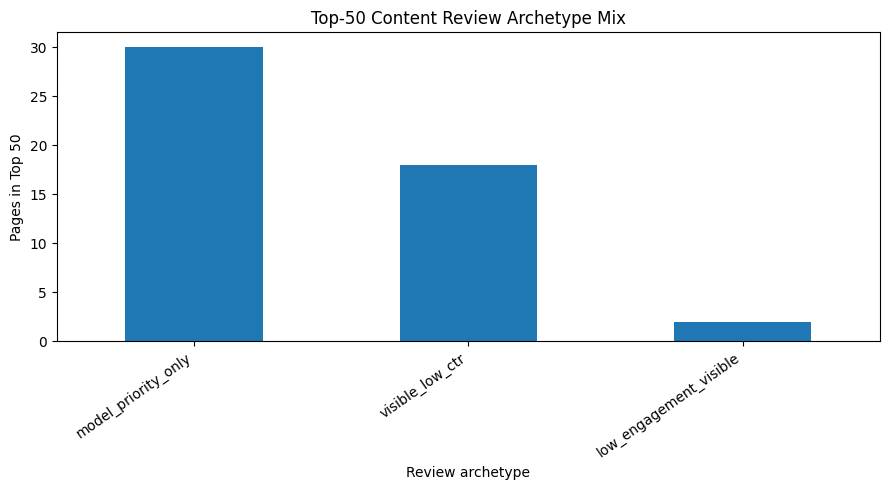

Queue: work/outputs/w07_ranked_action_queue.csv
Metrics: work/outputs/w07_playbook_metrics.json
Figure: work/figures/w07_top50_action_mix.png

Rows exported: 5783
Top-50 rows: 50

Top-50 archetype counts:
archetype
model_priority_only       30
visible_low_ctr           18
low_engagement_visible     2
Name: count, dtype: int64

Metrics receipt:
{
  "validation_design": "client_grouped_holdout",
  "queue_scope": "held_out_test_clients_only",
  "raw_rows": 30000,
  "complete_case_rows": 19897,
  "training_clients": 20,
  "held_out_clients": 9,
  "client_overlap": 0,
  "rows_scored": 5783,
  "review_capacity": 50,
  "grouped_rf_precision_at_50": 0.72,
  "grouped_rf_roc_auc": 0.6124710124616183,
  "impressions_baseline_precision_at_50": 0.52,
  "grouped_test_base_rate": 0.6228601072107902,
  "target_definition": "trend_direction == 'down'",
  "claim_scope": "decision-support ranking for the observed snapshot; not prospective forecasting"
}


In [5]:
import os
import json
import matplotlib.pyplot as plt

os.makedirs(
    "work/outputs",
    exist_ok=True
)

os.makedirs(
    "work/figures",
    exist_ok=True
)

# 1. Ranked action queue

export_queue = queue[
    public_queue_columns
].copy()

QUEUE_PATH = (
    "work/outputs/"
    "w07_ranked_action_queue.csv"
)

export_queue.to_csv(
    QUEUE_PATH,
    index=False
)

# 2. Metrics receipt JSON

METRICS_PATH = (
    "work/outputs/"
    "w07_playbook_metrics.json"
)

metrics_receipt = {
    "validation_design":
        "client_grouped_holdout",

    "queue_scope":
        "held_out_test_clients_only",

    "raw_rows":
        int(len(df)),

    "complete_case_rows":
        int(len(model_df)),

    "training_clients":
        int(train_df["client_id"].nunique()),

    "held_out_clients":
        int(test_df["client_id"].nunique()),

    "client_overlap":
        int(
            len(
                set(train_df["client_id"])
                & set(test_df["client_id"])
            )
        ),

    "rows_scored":
        int(len(export_queue)),

    "review_capacity":
        int(REVIEW_CAPACITY),

    "grouped_rf_precision_at_50":
        float(grouped_p50),

    "grouped_rf_roc_auc":
        float(grouped_auc),

    "impressions_baseline_precision_at_50":
        float(baseline_p50),

    "grouped_test_base_rate":
        float(base_rate),

    "target_definition":
        "trend_direction == 'down'",

    "claim_scope":
        "decision-support ranking for the observed snapshot; not prospective forecasting",
}

with open(
    METRICS_PATH,
    "w"
) as f:
    json.dump(
        metrics_receipt,
        f,
        indent=2
    )
# 3. Paper figure: Top-50 action / archetype mix
top50 = export_queue[
    export_queue["rank"] <= REVIEW_CAPACITY
].copy()

action_counts = (
    top50["archetype"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

action_counts.plot(
    kind="bar"
)

plt.title(
    "Top-50 Content Review Archetype Mix"
)

plt.xlabel(
    "Review archetype"
)

plt.ylabel(
    "Pages in Top 50"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()

FIGURE_PATH = (
    "work/figures/"
    "w07_top50_action_mix.png"
)

plt.savefig(
    FIGURE_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# Export checks

print("Queue:", QUEUE_PATH)
print("Metrics:", METRICS_PATH)
print("Figure:", FIGURE_PATH)

print(
    "\nRows exported:",
    len(export_queue)
)

print(
    "Top-50 rows:",
    len(top50)
)

print(
    "\nTop-50 archetype counts:"
)

print(action_counts)

print(
    "\nMetrics receipt:"
)

print(
    json.dumps(
        metrics_receipt,
        indent=2
    )
)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.